## Temporal Analysis
Análisis de latencias de las distintas partes del algoritmo


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
#file_name = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\no_labels_test_times.csv'
file_name = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\github\photoneu\raspberryPi\logs\no_labels_test_times.csv'
df_time = pd.DataFrame() 
df_time = pd.read_csv(file_name)

df_time.drop(df_time.columns[0], axis=1, inplace=True)
df_time = df_time*1000
df_time["total"] = df_time.sum(axis=1)
df_time.head()

,t_init_resize,t_gray_norm,t_blur,t_thres,t_erosion,t_opening,t_blobs,total
0,14.9421,3.9782,1.4741,0.6002,3.8266,0.1478,11.6095,36.5785
1,8.3204,0.0995,0.8872,0.0322,0.0710,0.1452,6.4797,16.0352
2,9.1516,0.1622,1.4224,0.0612,0.1184,0.2153,9.5333,20.6644
3,8.8133,0.1358,1.5264,0.0443,0.0972,0.2117,2.2436,13.0723
4,7.3093,0.0912,0.8781,0.0340,0.0756,0.1555,2.3111,10.8548


In [ ]:
#df = df.drop(df.columns[0], axis = 1)
df_time
plt.figure()
sns.boxplot(data=df_time[df_time.columns[0]])  # Crear el diagrama de violín sin la línea interior

#for i, col in enumerate(df.columns):
mean = df_time[df_time.columns[0]].mean()
std = df_time[df_time.columns[0]].std()
plt.text(0, mean - 0.2, f'Mean: {mean:.2f}', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
    
#    plt.text(i, mean + 1.5*std, f'+1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)
#    plt.text(i, mean - 1.5*std, f'-1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)

# Configurar etiquetas y título
#plt.ylim(0,5)
plt.title('Latencias en la captura de imágenes de test')
plt.xlabel('Lectura y cambio de tamaño del fichero de la imágen de test.')
plt.grid(True)
plt.ylabel('Latencia en ms')

# Mostrar el gráfico
plt.show()

In [32]:
df_time_total = df_time.copy()
df_time = df_time.drop(df_time.columns[-1], axis = 1)

C:\Users\inges\AppData\Local\Temp\ipykernel_69100\1406571275.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  box.set_xticklabels(col_names, rotation=20, ha='center')


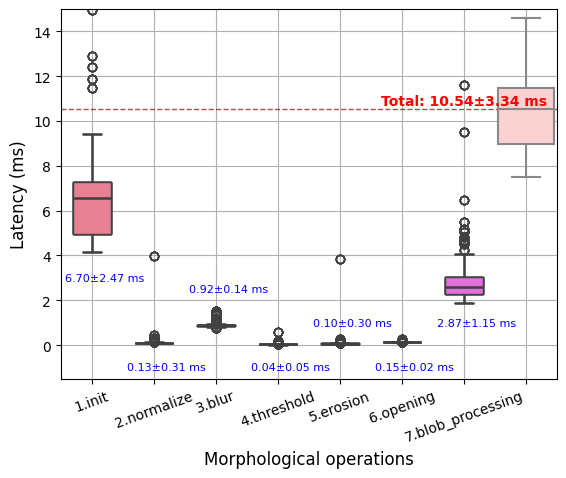

In [ ]:

plt.figure()
col_names = ["1.init", "2.normalize","3.blur","4.threshold","5.erosion","6.opening","7.blob_processing"]
pos = [3, -1, 2.5,-1, 1, -1, 1]
for i, col in enumerate(df_time.columns):
    mean = df_time[df_time.columns[i]].mean()
    std = df_time[df_time.columns[i]].std()
    box = sns.boxplot(data=df_time,
                      width=0.6,
                     linewidth=1,
#                     flierprops=dict(marker='o', 
#                                   markersize=4,
#                                   markerfacecolor="#FF6B6B",
#                                   markeredgecolor='none',
#                                   alpha=0.6)
     ) 
    plt.text(i + 0.20, pos[i], f'{mean:.2f}' + "±" + f'{std:.2f}' + " ms" , ha='center', va='center', color='blue', fontsize=8)    
#    plt.text(i, mean + 1.5*std, f'+1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)
#    plt.text(i, mean - 1.5*std, f'-1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)
# Configurar etiquetas y título
total_mean = df_time_total["total"].median()
total_std = df_time_total["total"].std()
l = total_mean*np.ones(col_names.__len__())
plt.axhline(y=total_mean, color='darkred', linestyle='--', linewidth=1, alpha=0.7)
#plt.plot(l, linestyle = 'dotted', linewidth=2)
plt.text(6, total_mean + 0.1*total_std, f'Total: {total_mean:.2f}' + "±" + f'{total_std:.2f}' + " ms", ha='center', va='center', color='red', fontsize=10, fontweight='bold')
sns.boxplot(data=df_time_total["total"], color='#FFCCCB', width=0.9, fliersize=0, linewidth=1.5, boxprops=dict(alpha=1), ax=box)
plt.ylim(-1.5,16)
#plt.title('Latencies for different morphological operations') 
plt.xlabel('Morphological operations')
#plt.title('Latencias en la captura de imágenes de test')
#plt.xlabel('Lectura y cambio de tamaño del fichero de la imágen de test.')
box.set_xticklabels(col_names, rotation=20, ha='center')
plt.grid(True)
plt.ylabel('Latency (ms)')
#plt.ylabel('Latencia en ms')

# Mostrar el gráfico
plt.show()

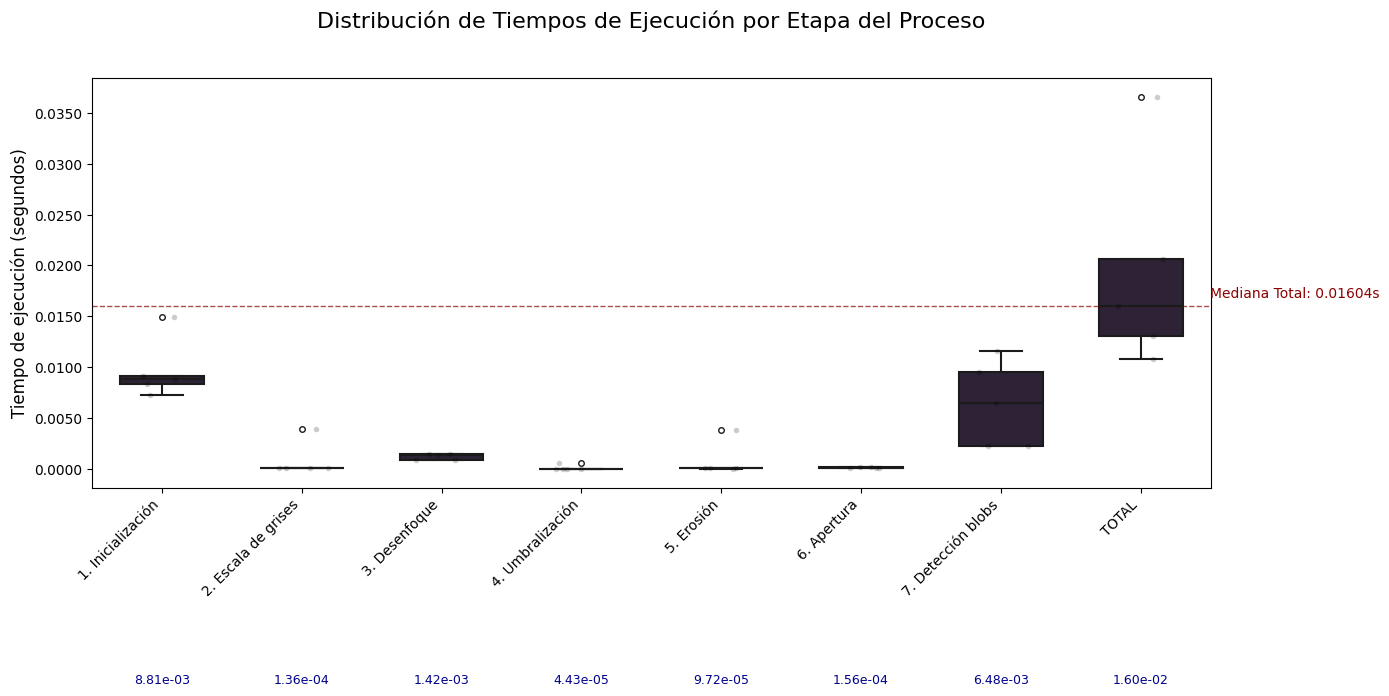

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# Configuración estética
#plt.style.use('seaborn-whitegrid')
sns.set_palette("mako")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Cargar datos (simulando tu dataset)
# En tu caso, usarías: data = pd.read_csv('tu_archivo.csv')
data = pd.DataFrame({
    't_init_resize': [0.0149421, 0.0083204, 0.0091516, 0.0088133, 0.0073093],
    't_gray_norm': [0.0039782, 9.95e-05, 0.0001622, 0.0001358, 9.12e-05],
    't_blur': [0.0014741, 0.0008872, 0.0014224, 0.0015264, 0.0008781],
    't_thres': [0.0006002, 3.22e-05, 6.12e-05, 4.43e-05, 3.4e-05],
    't_erosion': [0.0038266, 7.1e-05, 0.0001184, 9.72e-05, 7.56e-05],
    't_opening': [0.0001478, 0.0001452, 0.0002153, 0.0002117, 0.0001555],
    't_blobs': [0.0116095, 0.0064797, 0.0095333, 0.0022436, 0.0023111]
})

# Añadir columna de suma total
data['Total'] = data.sum(axis=1)

# Renombrar columnas para mejor visualización
nombres_amigables = {
    't_init_resize': '1. Inicialización',
    't_gray_norm': '2. Escala de grises',
    't_blur': '3. Desenfoque',
    't_thres': '4. Umbralización',
    't_erosion': '5. Erosión',
    't_opening': '6. Apertura',
    't_blobs': '7. Detección blobs',
    'Total': 'TOTAL'
}

# Preparar datos en formato largo para Seaborn
data_melted = data.rename(columns=nombres_amigables).melt(var_name='Operación', value_name='Tiempo (s)')

# Orden personalizado para las operaciones
orden_operaciones = list(nombres_amigables.values())

# Crear figura
fig, ax = plt.subplots(figsize=(14, 8))

# Boxplot principal
sns.boxplot(
    x='Operación', 
    y='Tiempo (s)', 
    data=data_melted, 
    order=orden_operaciones,
    width=0.6,
    linewidth=1.5,
    fliersize=4,
    ax=ax
)

# Añadir puntos para mostrar distribución real
sns.stripplot(
    x='Operación', 
    y='Tiempo (s)', 
    data=data_melted, 
    order=orden_operaciones,
    color='black', 
    alpha=0.2,
    size=4,
    jitter=0.2,
    ax=ax
)

# Personalización del gráfico
ax.set_title('Distribución de Tiempos de Ejecución por Etapa del Proceso\n', fontsize=16, pad=20)
ax.set_xlabel('', fontsize=12)
ax.set_ylabel('Tiempo de ejecución (segundos)', fontsize=12)

# Formatear eje Y para notación científica cuando sea necesario
ax.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))

# Rotar etiquetas del eje X para mejor legibilidad
plt.xticks(rotation=45, ha='right')

# Añadir línea horizontal en el total para comparación
ax.axhline(y=data['Total'].median(), color='darkred', linestyle='--', linewidth=1, alpha=0.7)
ax.text(7.5, data['Total'].median()*1.05, f'Mediana Total: {data["Total"].median():.5f}s', 
        color='darkred', fontsize=10)

# Añadir anotaciones estadísticas
for i, op in enumerate(orden_operaciones):
    median_val = data_melted[data_melted['Operación'] == op]['Tiempo (s)'].median()
    ax.text(i, -0.02, f'{median_val:.2e}', 
            ha='center', va='top', fontsize=9, color='darkblue')

# Ajustar layout
plt.tight_layout()

# Mostrar gráfico
plt.show()